[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Python-for-AI-Driven-Automation/blob/main/fast_track/16_model_evaluation_and_feature_engineering.ipynb)

# 📓 Notebook 16 (fast track) — Model Evaluation & Feature Engineering

> **Module:** Machine Learning · **Estimated time:** 75–90 min · **Difficulty:** Intermediate

In NB 8 you trained your first scikit-learn models and read off `accuracy`. That's enough to *start*; it is not enough to *ship*. Two skills separate a demo from a real model: **evaluating honestly** (a single accuracy number hides which mistakes you make and how much luck is in the score) and **engineering features** (the model can only learn what the columns tell it — and one careless column can hand it the answer). This notebook covers both, back to back, on one small dataset.

> 🏎️ **You're on the fast track.** This is a trimmed, **combined** notebook that condenses two canonical chapters into one: [`04_machine_learning/15_model_evaluation.ipynb`](../04_machine_learning/15_model_evaluation.ipynb) (evaluation) and [`04_machine_learning/16_feature_engineering.ipynb`](../04_machine_learning/16_feature_engineering.ipynb) (feature engineering). The hand-rolled proofs, the extra plots, and the bonus mini-projects are cut to keep the path lean — the core teaching, every checkpoint, and a double set of stretch exercises are kept. Open the canonical versions when you want the deeper material.

> 🧭 **Mental model for this notebook — two disciplines, one honest number.** *A single accuracy score lies.* **Part 1** teaches you to evaluate in the **currency of the decision**: a classifier hands you a *score*, and everything worth arguing about happens between that score and a real action — where you draw the line (the threshold, set by the **cost** of each mistake) and how much you trust the number (cross-validation, calibration). **Part 2** teaches you to build the features that feed the model — turning messy reality into honest numbers — under one golden rule: **never let a feature use the future or the target.** A leak is just Part 1's honest number, quietly corrupted at the source.

> **Prerequisites.** Fast-track **NB 8 (sklearn basics)** — the `fit` / `predict` / `Pipeline` contract and `train_test_split`.

## 🎯 Learning objectives

By the end of this notebook you can:

1. Read a **confusion matrix** in *cost units*, not just counts.
2. Choose between **precision**, **recall**, and **F1** by which mistake is more expensive.
3. Plot and interpret **ROC** and **precision–recall** curves.
4. Pick a decision **threshold** from a business cost — not the default 0.5.
5. Run **leak-proof cross-validation** and report an honest **mean ± std** (plus a word on calibration).
6. **Encode** categoricals, **scale** numerics, and **unpack datetime** columns into model-ready features.
7. Spot and remove **target leakage**, and bundle every step into a leak-free **`Pipeline` / `ColumnTransformer`**.

## 🛠️ Setup — one small churn table we carry the whole way through

Both halves use the **same seeded, synthetic SaaS-churn table** — a few hundred customers with a plan, a region, a signup date, and behavioural signals. Part 1 evaluates a churn classifier on it; Part 2 engineers features from the very same columns. Everything is offline: `numpy`, `pandas`, `matplotlib`, `seaborn`, and `scikit-learn`, no downloads.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (confusion_matrix, classification_report, roc_auc_score,
                             brier_score_loss, RocCurveDisplay, PrecisionRecallDisplay)
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 4)
RANDOM_STATE = 42

# --- Build the synthetic churn table (seeded, so everyone sees the same numbers) ---
rng = np.random.default_rng(RANDOM_STATE)
n = 600
mrr_eur         = rng.lognormal(mean=6.5, sigma=0.7, size=n).clip(50, 50_000)
months_active   = rng.integers(1, 60, size=n)
support_tickets = rng.poisson(lam=2.5, size=n)
plan            = rng.choice(["Free", "Standard", "Premium", "Enterprise"],
                             size=n, p=[0.15, 0.45, 0.30, 0.10])
last_login_days = rng.integers(0, 90, size=n)
signup_date     = pd.to_datetime("2023-01-01") + pd.to_timedelta(rng.integers(0, 365, size=n), unit="D")
region          = rng.choice(["EU", "US", "APAC", "LATAM"], size=n, p=[0.40, 0.40, 0.15, 0.05])

# A hidden "happiness" score drives churn — so the features carry real signal.
plan_adj  = np.array([{"Free": -0.45, "Standard": 0.0, "Premium": 0.15, "Enterprise": 0.35}[p] for p in plan])
happiness = (-0.40 * (support_tickets - 2.5) / 2.0
             - 0.80 * (last_login_days - 45) / 30.0
             + 0.35 * (np.log1p(mrr_eur) - 6.5) / 1.5
             + 0.30 * (months_active - 30) / 20.0
             + plan_adj + rng.normal(0, 0.30, n))
churn_prob = 1 / (1 + np.exp(-(-1.6 - 2.5 * happiness)))
churned    = (rng.random(n) < churn_prob).astype(int)

df = pd.DataFrame({
    "mrr_eur": mrr_eur, "months_active": months_active, "support_tickets": support_tickets,
    "plan": plan, "last_login_days": last_login_days, "signup_date": signup_date,
    "region": region, "churned": churned,
})
print(df.head())
print(f"\nShape: {df.shape}  ·  churn rate: {df['churned'].mean():.1%}")

       mrr_eur  months_active  support_tickets      plan  last_login_days  \
0   823.284606             15                1   Premium               81   
1   321.183023             25                4   Premium               27   
2  1124.749741              5                3   Premium               48   
3  1284.847485             47                3  Standard               18   
4   169.741275             39                2   Premium               68   

  signup_date region  churned  
0  2023-08-19     EU        0  
1  2023-12-11     US        1  
2  2023-10-02   APAC        1  
3  2023-09-18     EU        0  
4  2023-02-10     EU        1  

Shape: (600, 8)  ·  churn rate: 28.7%


# 📊 Part 1 — Honest Model Evaluation  *(condensed from [`04_machine_learning/15_model_evaluation.ipynb`](../04_machine_learning/15_model_evaluation.ipynb))*

A classifier doesn't hand you a decision — it hands you a **score** between 0 and 1. Every tool below turns that score into a trustworthy decision, asking one escalating question: **is this model safe to ship?**

## 1. Two models, one split

We train the two models from NB 8 — a **logistic regression** and a **random forest** — inside a `Pipeline` so preprocessing can never leak. What we keep is *not* the 0/1 labels but the raw probability scores `p_lr` and `p_rf`: the score is the real output.

In [2]:
X = df.drop(columns=["churned", "signup_date"])   # drop the raw date; we model the rest
y = df["churned"].to_numpy()
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)

NUM = ["mrr_eur", "months_active", "support_tickets", "last_login_days"]
CAT = ["plan", "region"]
prep = ColumnTransformer([
    ("num", StandardScaler(), NUM),
    ("cat", OneHotEncoder(handle_unknown="ignore"), CAT),
], remainder="drop")

logreg  = Pipeline([("prep", prep), ("model", LogisticRegression(max_iter=500, random_state=RANDOM_STATE))])
rforest = Pipeline([("prep", prep), ("model", RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1))])
logreg.fit(X_tr, y_tr)
rforest.fit(X_tr, y_tr)

p_lr = logreg.predict_proba(X_te)[:, 1]     # P(churn) from the logistic regression
p_rf = rforest.predict_proba(X_te)[:, 1]    # P(churn) from the random forest
print(f"LR accuracy: {logreg.score(X_te, y_te):.3f}   ·   RF accuracy: {rforest.score(X_te, y_te):.3f}")
print(f"Test set: {len(y_te)} customers, churn rate {y_te.mean():.1%}")

LR accuracy: 0.750   ·   RF accuracy: 0.808
Test set: 120 customers, churn rate 28.3%


## 2. The confusion matrix — read it in **cost units** 🔬

Pick a line (the obvious first guess is `0.5`) and every prediction lands in one of four boxes:

```text
                  Predicted: stayed        Predicted: churned
   Actual: stayed        TN                FP  (false alarm — pestered a happy customer)
   Actual: churned  FN (missed churner)    TP  (correctly caught the churner)
```

The metric you optimise depends on **which mistake is more expensive**. Here a false alarm costs a few dollars of retention-team time; a missed churner costs a whole customer's lifetime value.

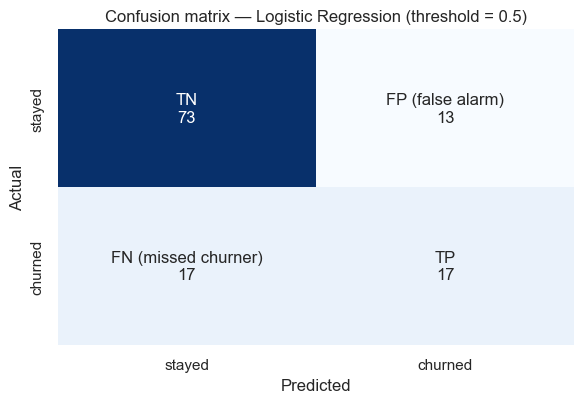

With FP=$5, FN=$200:  total cost = $3,465


In [3]:
y_pred_lr = (p_lr >= 0.5).astype(int)
cm = confusion_matrix(y_te, y_pred_lr)

quad = np.array([[f"TN\n{cm[0,0]}",                  f"FP (false alarm)\n{cm[0,1]}"],
                 [f"FN (missed churner)\n{cm[1,0]}", f"TP\n{cm[1,1]}"]])
plt.figure(figsize=(6, 4.2))
sns.heatmap(cm, annot=quad, fmt="", cmap="Blues", cbar=False,
            xticklabels=["stayed", "churned"], yticklabels=["stayed", "churned"])
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Confusion matrix — Logistic Regression (threshold = 0.5)")
plt.tight_layout(); plt.show()

COST_FP = 5      # cost of a false alarm (retention-team minutes)
COST_FN = 200    # cost of losing a churner (lifetime value)
total_cost = cm[0, 1] * COST_FP + cm[1, 0] * COST_FN
print(f"With FP=${COST_FP}, FN=${COST_FN}:  total cost = ${total_cost:,}")

> 🎯 **The cost asymmetry decides which model wins.** A model with slightly *worse* accuracy can be the right choice if its mistakes are the *cheap* ones.

---

### ✋ Quick exercise (~2 min) — Re-price the mistakes

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

Finance revises the numbers: a false alarm now costs **\$10** and a missed churner **\$150**. Reuse the confusion matrix `cm` (LR at threshold 0.5) and compute the new **total cost** — no re-fitting needed.

In [4]:
# ✍️ Your turn 👇
# Reuse the confusion matrix `cm`. A false alarm (cm[0,1]) now costs $10,
# a missed churner (cm[1,0]) costs $150. Print the new total cost.

<details>
<summary>✅ <b>Solution</b></summary>

```python
new_cost = cm[0, 1] * 10 + cm[1, 0] * 150
print(f"Revised total cost = ${new_cost:,}")
```

Same confusion matrix, new prices — only the cell *weights* changed. The model's mistakes are identical; what changed is how much each one hurts.
</details>

## 3. Precision, recall, F1 — three numbers, one trade-off

- **Precision** — of everyone we *flagged* as churn, how many really churned? *(High = few false alarms.)*
- **Recall** — of everyone who *really* churned, how many did we catch? *(High = few misses.)*
- **F1** — the harmonic mean of the two; it punishes a lopsided model.

In [5]:
print(classification_report(y_te, y_pred_lr, target_names=["stayed", "churned"],
                            digits=3, zero_division=0))

              precision    recall  f1-score   support

      stayed      0.811     0.849     0.830        86
     churned      0.567     0.500     0.531        34

    accuracy                          0.750       120
   macro avg      0.689     0.674     0.680       120
weighted avg      0.742     0.750     0.745       120



> ⚠️ **On imbalanced data, `accuracy` lies.** If 75% of customers stay, predicting "stay" for *everyone* scores 0.75 accuracy and **zero recall** — a useless model that a single accuracy number can't distinguish from a good one. Always pair accuracy with the confusion matrix and class-wise precision/recall.

## 4. ROC & PR curves — every threshold at once

Both curves sweep the threshold from 0 to 1 so you can judge a model *before* committing to a line.

- **ROC** plots true-positive rate vs false-positive rate; the area (**AUC**) is insensitive to class imbalance.
- **PR** plots precision vs recall; more informative when positives are **rare**.

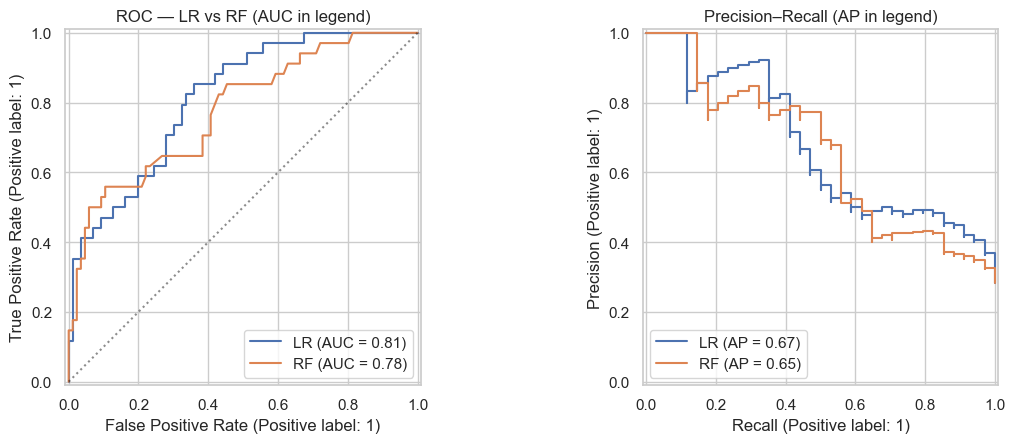

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
for name, p in [("LR", p_lr), ("RF", p_rf)]:
    RocCurveDisplay.from_predictions(y_te, p, name=name, ax=axes[0])
    PrecisionRecallDisplay.from_predictions(y_te, p, name=name, ax=axes[1])
axes[0].plot([0, 1], [0, 1], "k:", alpha=0.5)     # chance line
axes[0].set_title("ROC — LR vs RF (AUC in legend)")
axes[1].set_title("Precision–Recall (AP in legend)")
plt.tight_layout(); plt.show()

| Situation | Look at |
|---|---|
| Balanced classes, comparing overall ranking | **ROC + AUC** |
| Rare positives (imbalanced) | **PR curve + AP** |
| A wildly skewed cost ratio | **cost vs threshold** (next) |

## 5. Choosing the threshold from a business cost

The `0.5` line is a *default, not a law*. Moving it re-fits **nothing** — it just re-reads the same scores. Sweep the threshold, price each confusion matrix, and pick the minimum-cost point.

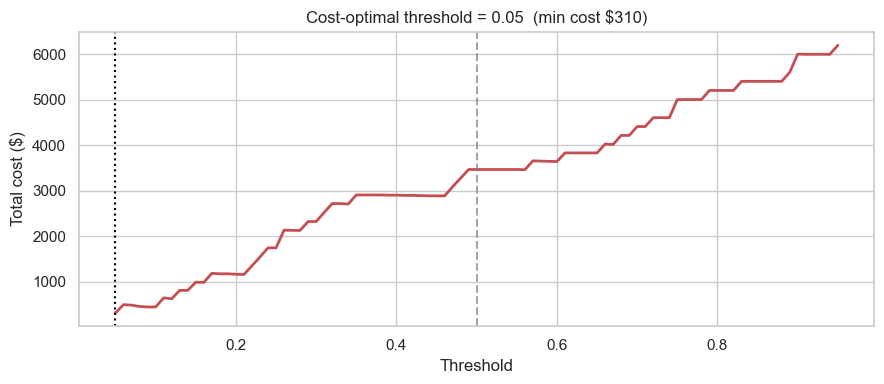

Cost at 0.50 = $3,465   →   cost at 0.05 = $310   (saves $3,155 on this test set)


In [7]:
thresholds = np.linspace(0.05, 0.95, 91)
costs = []
for t in thresholds:
    m = confusion_matrix(y_te, (p_lr >= t).astype(int))
    costs.append(m[0, 1] * COST_FP + m[1, 0] * COST_FN)

best_i = int(np.argmin(costs))
t_opt  = thresholds[best_i]

plt.figure(figsize=(9, 4))
plt.plot(thresholds, costs, lw=2, color="#C44E52")
plt.axvline(t_opt, color="black", ls=":")
plt.axvline(0.5, color="grey", ls="--", alpha=0.7)
plt.xlabel("Threshold"); plt.ylabel("Total cost ($)")
plt.title(f"Cost-optimal threshold = {t_opt:.2f}  (min cost ${costs[best_i]:,})")
plt.tight_layout(); plt.show()

base_cost = costs[int(np.argmin(np.abs(thresholds - 0.5)))]
print(f"Cost at 0.50 = ${base_cost:,}   →   cost at {t_opt:.2f} = ${costs[best_i]:,}   "
      f"(saves ${base_cost - costs[best_i]:,} on this test set)")

> 🎯 **The threshold is a business decision, not a model property.** With a missed churner 40× more expensive than a false alarm, the optimum sits **well below** 0.5 — you'd rather over-flag than miss.

---

### ✋ Quick exercise (~2 min) — Move the line, watch recall

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

The retention team drops the threshold to **0.3** to catch more churners. Using `p_lr` and `confusion_matrix`, label the test set at 0.3 and compute the churn-class **recall** (`TP / (TP + FN)`). Is it higher or lower than at 0.5?

In [8]:
# ✍️ Your turn 👇
# Label LR's test predictions at threshold 0.3 (use p_lr), then compute
# recall for the churn class from the confusion matrix: recall = TP / (TP + FN).

<details>
<summary>✅ <b>Solution</b></summary>

```python
yp = (p_lr >= 0.3).astype(int)
m  = confusion_matrix(y_te, yp)
recall = m[1, 1] / (m[1, 0] + m[1, 1])     # TP / (FN + TP)
print(f"Recall at threshold 0.3 = {recall:.2%}")
```

Recall is the catch rate. Lowering the threshold flags *more* customers as churners, so it catches more real churners — recall **rises** versus the 0.5 default (at the price of more false alarms).
</details>

## 6. Cross-validation — the honest score 🧠

Every number above came from **one** train/test split — one roll of the dice. A lucky split flatters the model; an unlucky one punishes it, and you can't tell which you got. **Cross-validation** rotates the test slice over the whole dataset and reports a **mean ± std** you can defend.

> 🧠 **Mental model.** CV reuses scarce data by rotating which slice is the test set. Every row trains in *k−1* folds and tests in exactly one — *k* honest evaluations out of the same data. The **mean** is a less noisy estimate; the **std** is its error bar (`0.85 ± 0.02` is trustworthy, `0.85 ± 0.12` is a coin flip).

In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scores = cross_val_score(logreg, X, y, cv=cv, scoring="roc_auc", n_jobs=-1)
print(f"LR 5-fold ROC-AUC: {scores.round(3)}")
print(f"Mean ± std       : {scores.mean():.3f} ± {scores.std():.3f}")

LR 5-fold ROC-AUC: [0.789 0.837 0.854 0.895 0.858]
Mean ± std       : 0.846 ± 0.034


Two rules make CV honest: **stratify** on the target (keeps class balance stable across folds), and **pass the `Pipeline`, not a bare model** — so the scaler/encoder is re-fit on each fold's training rows only. That second rule is exactly the leakage discipline Part 2 is built around.

## 7. A quick word on calibration 🔬

A model says `P(churn) = 0.8`. Is that customer **80% likely** to churn — or did the model just *rank* them highly? A **well-calibrated** model satisfies "of everyone predicted at 0.8, ~80% actually churn." Tree models are great at *ranking* but often poorly *calibrated*; the **Brier score** (mean squared error of the probabilities, lower is better) summarises it, and `CalibratedClassifierCV` can fix it.

LR                 Brier = 0.157  (lower is better)
RF (uncalibrated)  Brier = 0.157  (lower is better)


RF (calibrated)    Brier = 0.155


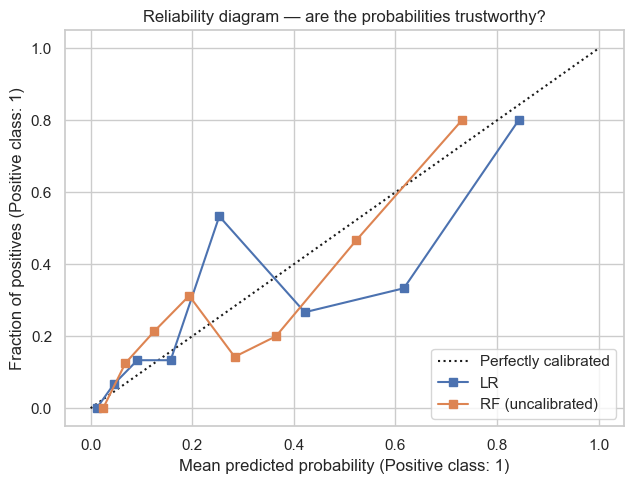

In [10]:
fig, ax = plt.subplots(figsize=(6.5, 5))
for name, p in [("LR", p_lr), ("RF (uncalibrated)", p_rf)]:
    CalibrationDisplay.from_predictions(y_te, p, n_bins=8, strategy="quantile", name=name, ax=ax)
    print(f"{name:<18} Brier = {brier_score_loss(y_te, p):.3f}  (lower is better)")

rf_cal   = CalibratedClassifierCV(rforest, method="isotonic", cv=3).fit(X_tr, y_tr)
p_rf_cal = rf_cal.predict_proba(X_te)[:, 1]
print(f"{'RF (calibrated)':<18} Brier = {brier_score_loss(y_te, p_rf_cal):.3f}")

ax.set_title("Reliability diagram — are the probabilities trustworthy?")
plt.tight_layout(); plt.show()

Points on the dotted diagonal are perfectly calibrated; **below** = over-confident, **above** = under-confident. The gain from calibration is small here because this forest is already near-calibrated and the test set is tiny — but on a real, larger dataset it often matters a lot.

# 🏗️ Part 2 — Feature Engineering  *(condensed from [`04_machine_learning/16_feature_engineering.ipynb`](../04_machine_learning/16_feature_engineering.ipynb))*

A model is just arithmetic — it multiplies, adds, and compares **numbers**. Feature engineering is translating messy reality (a category, a date, a pair of columns) into honest numbers, while *preserving* real structure and *not inventing* fake structure — and never letting a feature peek at the future or the target.

> 🧭 **The golden rule (mental model #2).** A feature may only use information that would exist **at prediction time**. Any number computed using the answer — or using rows that don't exist yet — is **leakage**, and it turns Part 1's honest score into a lie. Every "fit on train only / inside a `Pipeline`" rule below is one corollary of this single rule.

## 8. Encoding categoricals — three options, three trade-offs

`plan` holds strings, and you can't multiply by `"Premium"`. Turn a category into numbers *without inventing a fake order*:

| Encoding | Use when | Avoid when |
|---|---|---|
| **One-hot** | few categories, no order | hundreds of categories (explodes width) |
| **Ordinal** | a *real* order (`Free < … < Enterprise`) | nominal data — injects a false order |
| **Target / mean** | many categories, enough data | small data — leaks the target unless done per-fold |

In [11]:
# (a) One-hot: one 0/1 column per category — exactly one 1 per row
oh = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
X_oh = oh.fit_transform(df[["plan"]])
print("One-hot encoding of 'plan':")
print(pd.DataFrame(X_oh, columns=oh.get_feature_names_out(["plan"])).head(), "\n")

# (b) Ordinal: only valid because plan has a TRUE order
ord_enc = OrdinalEncoder(categories=[["Free", "Standard", "Premium", "Enterprise"]])
plan_ord = ord_enc.fit_transform(df[["plan"]]).astype(int).ravel()
print("Ordinal encoding (order is real here):")
print(pd.DataFrame({"plan": df["plan"], "ordinal": plan_ord}).drop_duplicates().sort_values("ordinal"), "\n")

# (c) Does 'plan' even carry signal? Churn rate per plan = what target encoding would store.
print("Churn rate by plan (the signal that makes 'plan' worth encoding):")
print(df.groupby("plan")["churned"].mean().reindex(["Free", "Standard", "Premium", "Enterprise"]).round(3))

One-hot encoding of 'plan':
   plan_Enterprise  plan_Free  plan_Premium  plan_Standard
0              0.0        0.0           1.0            0.0
1              0.0        0.0           1.0            0.0
2              0.0        0.0           1.0            0.0
3              0.0        0.0           0.0            1.0
4              0.0        0.0           1.0            0.0 

Ordinal encoding (order is real here):
          plan  ordinal
18        Free        0
3     Standard        1
0      Premium        2
19  Enterprise        3 

Churn rate by plan (the signal that makes 'plan' worth encoding):
plan
Free          0.392
Standard      0.288
Premium       0.258
Enterprise    0.197
Name: churned, dtype: float64


> 🧠 **Mental model.** One-hot gives each category its **own private switch** — flipping "Premium" on says *nothing* about "Free." Integer-encoding forces every category onto **one shared dial**, which always implies order and distance. Use integers only when the order is real.
>
> ⚠️ **The classic ordinal mistake.** A column of `["red", "green", "blue"]` is *not* ordinal — `green` is not "between" red and blue. Ordinal-encoding nominal data injects a fictitious order the model will dutifully try to learn.

---

### ✋ Quick exercise (~2 min) — One-hot encode `region`

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

Marketing wants `region` as model-ready features. Using the same `OneHotEncoder` pattern you just saw for `plan`, fit an encoder on `df[["region"]]` and preview the encoded columns.

In [12]:
# ✍️ Your turn 👇
# Fit a OneHotEncoder on df[["region"]] and preview the resulting one-hot columns.

<details>
<summary>✅ <b>Solution</b></summary>

```python
oh_region = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
X_region  = oh_region.fit_transform(df[["region"]])
print(pd.DataFrame(X_region, columns=oh_region.get_feature_names_out(["region"])).head())
```

`region` is a *nominal* categorical with 4 values, so one-hot — one 0/1 column per category — is the safe default. No fake order gets injected.
</details>

## 9. Scaling — when it matters, when it doesn't

`mrr_eur` runs 50–50,000 while `support_tickets` is 0–10. A **distance/gradient** model (k-NN, logistic regression, SVM) sees `mrr_eur` as ~1000× more important *just because of its scale*. **Tree** models split one feature at a time and don't care. Watch scaling lift k-NN but leave the forest unchanged (scored with ROC-AUC, since the ~25% base rate makes accuracy trivial):

In [13]:
NUM_S = ["mrr_eur", "months_active", "support_tickets", "last_login_days"]
Xs, ys = df[NUM_S], df["churned"]
Xs_tr, Xs_te, ys_tr, ys_te = train_test_split(Xs, ys, test_size=0.20,
                                              random_state=RANDOM_STATE, stratify=ys)

knn_raw    = KNeighborsClassifier().fit(Xs_tr, ys_tr)
knn_scaled = Pipeline([("s", StandardScaler()), ("m", KNeighborsClassifier())]).fit(Xs_tr, ys_tr)
rf_plain   = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE).fit(Xs_tr, ys_tr)

def _auc(m):
    return roc_auc_score(ys_te, m.predict_proba(Xs_te)[:, 1])

print(f"k-NN, no scaling  : ROC-AUC = {_auc(knn_raw):.3f}")
print(f"k-NN, with scaler : ROC-AUC = {_auc(knn_scaled):.3f}   <- scaling lifts the distance model")
print(f"Random Forest     : ROC-AUC = {_auc(rf_plain):.3f}   <- trees are invariant to scale")

k-NN, no scaling  : ROC-AUC = 0.636
k-NN, with scaler : ROC-AUC = 0.740   <- scaling lifts the distance model
Random Forest     : ROC-AUC = 0.735   <- trees are invariant to scale


> 🔬 **Where the leak hides.** `StandardScaler` *learns* a mean and std in `.fit()` and stores them as `scaler.mean_` / `scaler.scale_` (the trailing `_` = "learned"). If you `fit` on the **whole** dataset before splitting, those stats are computed using the test rows — information flows backward and your score becomes a fantasy. The fix is the same as in Part 1: **put the scaler inside a `Pipeline`**, which re-fits it on each fold's training rows only. The test set stands in for genuinely unseen, future data; you can't take a mean over rows that don't exist yet.

## 10. Datetime features — unpack a date into many signals

`signup_date` is useless to arithmetic as-is, but it *contains* several features: tenure, month, day-of-week, season. We build them on a copy `dfx` so the original table stays clean.

In [14]:
dfx = df.copy()
ref = pd.Timestamp("2024-06-01")     # the "as-of" date — usually "now" in production

dfx["signup_year"]       = dfx["signup_date"].dt.year
dfx["signup_month"]      = dfx["signup_date"].dt.month
dfx["signup_dow"]        = dfx["signup_date"].dt.dayofweek         # 0 = Monday
dfx["tenure_days"]       = (ref - dfx["signup_date"]).dt.days
dfx["is_weekend_signup"] = (dfx["signup_dow"] >= 5).astype(int)

# Cyclical encoding: so December (12) and January (1) end up NEXT to each other, not 11 apart
dfx["signup_month_sin"] = np.sin(2 * np.pi * dfx["signup_month"] / 12)
dfx["signup_month_cos"] = np.cos(2 * np.pi * dfx["signup_month"] / 12)

print(dfx[["signup_date", "signup_month", "tenure_days", "is_weekend_signup",
           "signup_month_sin", "signup_month_cos"]].head())

  signup_date  signup_month  tenure_days  is_weekend_signup  signup_month_sin  \
0  2023-08-19             8          287                  1     -8.660254e-01   
1  2023-12-11            12          173                  0     -2.449294e-16   
2  2023-10-02            10          243                  0     -8.660254e-01   
3  2023-09-18             9          257                  0     -1.000000e+00   
4  2023-02-10             2          477                  0      8.660254e-01   

   signup_month_cos  
0     -5.000000e-01  
1      1.000000e+00  
2      5.000000e-01  
3     -1.836970e-16  
4      5.000000e-01  


> 💡 **Two habits worth keeping.** (1) `tenure_days` (days since signup) is a strong churn predictor almost for free. (2) **Cyclical encoding** with `sin`/`cos` fixes the wrap-around: a linear model reads `month=1` and `month=12` as 11 apart, but on the sin/cos circle they're neighbours. The same trick rescues hour-of-day and day-of-week.

## 11. Interaction & ratio features — help a linear model see non-linearity

Some signal lives only in a *combination*: "high MRR **and** never logs in" is an alarm neither column shows alone. A linear model adds features, it doesn't multiply them — so we hand it the combination directly.

In [15]:
# (a) Ratio: tickets per month of tenure — normalises by how long they've been a customer
dfx["tickets_per_month"] = dfx["support_tickets"] / dfx["months_active"].clip(lower=1)
# (b) Interaction: a Free-plan customer who has gone quiet
dfx["free_and_inactive"] = ((dfx["plan"] == "Free") & (dfx["last_login_days"] > 30)).astype(int)
# (c) Log of a heavy-tailed feature — pulls the long right tail toward the centre
dfx["log_mrr"] = np.log1p(dfx["mrr_eur"])

print(dfx[["mrr_eur", "log_mrr", "support_tickets", "months_active",
           "tickets_per_month", "free_and_inactive"]].head())

       mrr_eur   log_mrr  support_tickets  months_active  tickets_per_month  \
0   823.284606  6.714516                1             15           0.066667   
1   321.183023  5.775120                4             25           0.160000   
2  1124.749741  7.026205                3              5           0.600000   
3  1284.847485  7.159173                3             47           0.063830   
4   169.741275  5.140149                2             39           0.051282   

   free_and_inactive  
0                  0  
1                  0  
2                  0  
3                  0  
4                  0  


> 🎯 **Heavy-tailed features** (MRR, latency, follower counts) almost always benefit from `log1p` — it makes them usable *linearly*. Random forests find interactions on their own; linear models need them spelled out.

## 12. ⚠️ Target leakage — the bug that ruins ML projects

This is the golden rule cashed out. A feature is **leaky** when it holds information that wouldn't exist at prediction time — often the label in disguise, future information, or a group statistic computed over the whole dataset. The score looks spectacular in the notebook and **collapses in production**, because the model was quietly handed the answer.

Watch a leaky feature inflate the score — then watch it vanish when we remove it:

In [16]:
# A "leaky" feature: it secretly uses the target (dominant term), plus a little real signal.
leak_rng = np.random.default_rng(0)
dfx["total_engagement"] = (100 * (1 - dfx["churned"])          # <- leak: reads the answer
                           + 0.5 * dfx["months_active"]
                           + leak_rng.normal(0, 4, len(dfx)))

X_leak  = dfx[["mrr_eur", "months_active", "support_tickets", "total_engagement"]]
X_clean = dfx[["mrr_eur", "months_active", "support_tickets"]]     # same, minus the leak
leak_pipe = Pipeline([("s", StandardScaler()), ("m", LogisticRegression(max_iter=1000))])

auc_leak  = cross_val_score(leak_pipe, X_leak,  dfx["churned"], cv=5, scoring="roc_auc").mean()
auc_clean = cross_val_score(leak_pipe, X_clean, dfx["churned"], cv=5, scoring="roc_auc").mean()
print(f"With leaky feature   : CV ROC-AUC = {auc_leak:.3f}")
print(f"After removing it     : CV ROC-AUC = {auc_clean:.3f}")
print(f"corr(total_engagement, churned) = {dfx['total_engagement'].corr(dfx['churned']):+.3f}  (huge — investigate!)")

dfx = dfx.drop(columns=["total_engagement"])     # remove the leak before we build the real pipeline

With leaky feature   : CV ROC-AUC = 1.000
After removing it     : CV ROC-AUC = 0.670
corr(total_engagement, churned) = -0.980  (huge — investigate!)


**That jump is the smell.** A new feature that lifts CV by 10+ points with no extra data and no model change is almost always a leak. Before trusting a "great" feature, ask:

- Could this value have been measured **before** the event you're predicting?
- Is it an aggregate computed on the **whole** dataset instead of training only?
- Does it correlate with the target above ~0.9 by itself?

If any answer is "yes / not sure", investigate before you ship.

## 13. A complete leak-free `Pipeline`

The payoff. Every move from this part — encode categories, scale numbers, unpack the date, add interactions — now lives inside **one** `ColumnTransformer` + `Pipeline`. Because they travel *with* the model, the golden rule is enforced automatically: each transformer learns its numbers from the training fold only, so cross-validation stays honest no matter how elaborate the preprocessing gets.

In [17]:
NUM_FEATURES = ["mrr_eur", "log_mrr", "months_active", "support_tickets",
                "last_login_days", "tickets_per_month", "tenure_days",
                "signup_month_sin", "signup_month_cos", "is_weekend_signup"]
CAT_FEATURES = ["plan", "region"]

preprocess = ColumnTransformer([
    ("num", StandardScaler(), NUM_FEATURES),
    ("cat", OneHotEncoder(handle_unknown="ignore"), CAT_FEATURES),
], remainder="drop")

clean_pipe = Pipeline([("prep", preprocess), ("model", LogisticRegression(max_iter=1000))])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scores = cross_val_score(clean_pipe, dfx, dfx["churned"], cv=cv, scoring="roc_auc")
print(f"Leak-free pipeline — 5-fold ROC-AUC: {scores.round(3)}")
print(f"Mean ± std: {scores.mean():.3f} ± {scores.std():.3f}")

Leak-free pipeline — 5-fold ROC-AUC: [0.768 0.831 0.846 0.898 0.828]
Mean ± std: 0.834 ± 0.042


Every transformer is fit on each fold's *training* portion only, then applied to its validation portion. There is no path for validation data to influence a transformer's parameters. **That is what "no leakage" means in code.**

## 🧪 Practice exercises

Because this notebook combines two chapters, it carries a fuller set — six practice exercises spanning both halves, then a double set of stretch exercises. Try each before opening its solution.

### Exercise 1 — ⭐ Cost-optimal threshold for the Random Forest

Using `p_rf` and `y_te`, find the threshold in `np.linspace(0.05, 0.95, 91)` that minimises total cost with `COST_FP = 20` and `COST_FN = 100`. Print the optimal threshold and how it compares to 0.5.

In [18]:
# Your code here  👇

<details>
<summary>💡 <b>Solution</b></summary>

```python
CFP, CFN = 20, 100
grid = np.linspace(0.05, 0.95, 91)
costs = [confusion_matrix(y_te, (p_rf >= t).astype(int))[0, 1] * CFP
         + confusion_matrix(y_te, (p_rf >= t).astype(int))[1, 0] * CFN for t in grid]
best_t = grid[int(np.argmin(costs))]
print(f"Cost-optimal threshold = {best_t:.2f}  (min cost ${min(costs):,})")
print(f"Cost at 0.50           = ${costs[int(np.argmin(np.abs(grid - 0.5)))]:,}")
```

With a false negative 5× a false positive, the optimum sits **below** 0.5 — you'd rather over-flag than miss. The exact number shifts with the cost ratio, which is why you always tune it on real prices.
</details>

### Exercise 2 — ⭐⭐ Calibrate the logistic regression

Draw a reliability diagram for `p_lr` and print its Brier score next to the RF's (`p_rf`) and the calibrated RF's (`p_rf_cal`). Which model is best calibrated *by construction*, and why?

In [19]:
# Your code here  👇

<details>
<summary>💡 <b>Solution</b></summary>

```python
CalibrationDisplay.from_predictions(y_te, p_lr, n_bins=8, strategy="quantile", name="LR")
plt.title("Reliability diagram — Logistic Regression"); plt.tight_layout(); plt.show()

print(f"Brier — LR              : {brier_score_loss(y_te, p_lr):.3f}")
print(f"Brier — RF uncalibrated : {brier_score_loss(y_te, p_rf):.3f}")
print(f"Brier — RF calibrated   : {brier_score_loss(y_te, p_rf_cal):.3f}")
```

Logistic regression is usually well-calibrated **by construction** — it optimises the log-likelihood, a proper scoring rule, so its outputs behave like real probabilities. Random forests optimise split purity, not probability quality, so they often need post-hoc calibration.
</details>

### Exercise 3 — ⭐⭐ Add tenure features and re-score

Add `tenure_months` (`tenure_days / 30`) and `is_long_tenure` (`tenure_months > 12`) to `dfx`, add them to a copy of `NUM_FEATURES`, and report whether the leak-free pipeline's CV ROC-AUC improves beyond the noise (2× the std).

In [20]:
# Your code here  👇

<details>
<summary>💡 <b>Solution</b></summary>

```python
dfx["tenure_months"]  = dfx["tenure_days"] / 30
dfx["is_long_tenure"] = (dfx["tenure_months"] > 12).astype(int)

new_num = NUM_FEATURES + ["tenure_months", "is_long_tenure"]
prep2 = ColumnTransformer([
    ("num", StandardScaler(), new_num),
    ("cat", OneHotEncoder(handle_unknown="ignore"), CAT_FEATURES),
])
pipe2 = Pipeline([("prep", prep2), ("model", LogisticRegression(max_iter=1000))])
s2 = cross_val_score(pipe2, dfx, dfx["churned"], cv=cv, scoring="roc_auc")
print(f"Original: {scores.mean():.3f} ± {scores.std():.3f}")
print(f"+ tenure: {s2.mean():.3f} ± {s2.std():.3f}")
```

If the lift is within one standard deviation, it's noise. The honest rule: a feature should beat the baseline by at least ~2× the std before you keep it — otherwise you're decorating, not improving.
</details>

### Exercise 4 — ⭐⭐ Spot the leak

A teammate proposes this feature for predicting churn. Is it leaky? If so, fix it.

```python
df["avg_churn_for_plan"] = df.groupby("plan")["churned"].transform("mean")
```

In [21]:
# Your code here  👇

<details>
<summary>💡 <b>Solution</b></summary>

**Yes — leaky.** `groupby("plan").transform("mean")` averages `churned` over the *entire* DataFrame, including the rows that will land in the test fold — so each row's feature is computed partly from its own target. The fix is to learn the per-plan means on **training data only**, then map them onto both splits:

```python
train_df, valid_df = train_test_split(df, test_size=0.25, stratify=df["churned"],
                                      random_state=RANDOM_STATE)
plan_means = train_df.groupby("plan")["churned"].mean()          # learned on train ONLY
train_df = train_df.assign(avg_churn_for_plan=train_df["plan"].map(plan_means))
valid_df = valid_df.assign(avg_churn_for_plan=valid_df["plan"].map(plan_means))
print(valid_df[["plan", "avg_churn_for_plan"]].head())
```

Safer still: `category_encoders.TargetEncoder(cv=5)` inside a `Pipeline`, which does the train-only fit on every fold for you.
</details>

### Exercise 5 — ⭐⭐ Compare three classifiers with stratified CV

On the toy Iris dataset, compare `LogisticRegression(max_iter=500)`, `KNeighborsClassifier(n_neighbors=5)`, and `RandomForestClassifier(n_estimators=200, random_state=0)` with 5-fold **stratified** accuracy. Print each model's mean ± std.

In [22]:
# Your code here  👇

<details>
<summary>💡 <b>Solution</b></summary>

```python
from sklearn.datasets import load_iris

X_iris, y_iris = load_iris(return_X_y=True)
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
models = {
    "logreg": LogisticRegression(max_iter=500),
    "knn-5":  KNeighborsClassifier(n_neighbors=5),
    "rf-200": RandomForestClassifier(n_estimators=200, random_state=0),
}
for name, m in models.items():
    s = cross_val_score(m, X_iris, y_iris, cv=cv5, scoring="accuracy")
    print(f"{name:>6}: {s.mean():.3f} ± {s.std():.3f}")
```

Report the **std** alongside the mean: a model at `0.96 ± 0.02` is a safer bet than one at `0.97 ± 0.06`, because it's more consistent fold to fold. A higher mean with a wide error bar can be luck.
</details>

### Exercise 6 — ⭐⭐ Debug me 🐞

The cell below is meant to report the churn-class **recall** from the confusion matrix, but it **crashes** — and even if it didn't, the formula is wrong. Find *both* bugs and fix them.

In [23]:
# 👇 Your fixed/corrected version goes here — write or paste it below.
# Buggy:
y_pred_db = (p_lr >= 0.5).astype(int)
tn, fp, fn, tp = confusion_matrix(y_te, y_pred_db)     # crashes here
recall = tp / (tp + fp)                                # ...and this is precision, not recall
print(f"Recall = {recall:.2%}")

ValueError: not enough values to unpack (expected 4, got 2)

<details>
<summary>💡 <b>Solution</b></summary>

Two bugs. **(1)** `confusion_matrix(...)` returns a **2×2 array**, so `tn, fp, fn, tp = confusion_matrix(...)` raises `ValueError: not enough values to unpack (expected 4, got 2)` — you have to flatten it with `.ravel()`. **(2)** `tp / (tp + fp)` is **precision**; recall is `tp / (tp + fn)`.

```python
y_pred_db = (p_lr >= 0.5).astype(int)
tn, fp, fn, tp = confusion_matrix(y_te, y_pred_db).ravel()   # .ravel() → 4 scalars
recall = tp / (tp + fn)                                       # recall = TP / (TP + FN)
print(f"Recall = {recall:.2%}")
```

`confusion_matrix(...).ravel()` is the idiom for pulling out `tn, fp, fn, tp` in that order. And precision vs recall is the classic mix-up: precision divides by everything you *flagged* (`tp + fp`); recall divides by everything that was *actually positive* (`tp + fn`).
</details>

## 🧠 Stretch exercises

Two pairs to mirror the two chapters this notebook combines — an **evaluation** pair (C, D) and a **feature-engineering** pair (C, D). Each is self-contained; try it before opening the solution.

### Stretch exercise C — ⭐⭐⭐ F-beta: when precision and recall aren't equal

Implement `f_beta(precision, recall, beta)` from scratch, then compute **F0.5** (precision-favouring) and **F2** (recall-favouring) for the LR model at threshold 0.5 (use `p_lr`, `y_te`). Which β fits churn, where a miss hurts far more than a false alarm?

In [24]:
# Your code here  👇

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
yp = (p_lr >= 0.5).astype(int)
tn, fp, fn, tp = confusion_matrix(y_te, yp).ravel()
precision = tp / (tp + fp)
recall    = tp / (tp + fn)

def f_beta(p, r, beta):
    if p == r == 0:
        return 0.0
    b2 = beta * beta
    return (1 + b2) * p * r / (b2 * p + r)

print(f"precision = {precision:.3f}   recall = {recall:.3f}")
print(f"F0.5 = {f_beta(precision, recall, 0.5):.3f}   (precision-favouring)")
print(f"F1   = {f_beta(precision, recall, 1.0):.3f}")
print(f"F2   = {f_beta(precision, recall, 2.0):.3f}   (recall-favouring)")
```

**Reasoning.** F-beta generalises F1 with a knob: β > 1 weights **recall** more, β < 1 weights **precision** more. For churn, **F2 is usually right** — a missed churner is gone (expensive), while a false alarm costs a few minutes of a CS rep's time (cheap). Always pick a metric whose β mirrors the business cost ratio, exactly as you picked the threshold from cost in Part 1.
</details>

### Stretch exercise D — ⭐⭐⭐ Compare two models with PR curves

On the built-in **breast-cancer** dataset, fit a `LogisticRegression` and a `RandomForestClassifier`, then plot their **precision–recall curves on one axis** and report **average precision (AP)** for each. Why PR rather than ROC when positives are rare?

In [25]:
# Your code here  👇
from sklearn.datasets import load_breast_cancer
X_bc, y_bc = load_breast_cancer(return_X_y=True)
# ...

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
from sklearn.datasets import load_breast_cancer

X_bc, y_bc = load_breast_cancer(return_X_y=True)
Xtr, Xte, ytr, yte = train_test_split(X_bc, y_bc, test_size=0.30,
                                      random_state=0, stratify=y_bc)
models = {
    "logreg": Pipeline([("s", StandardScaler()),
                        ("m", LogisticRegression(max_iter=10_000))]).fit(Xtr, ytr),
    "rf":     RandomForestClassifier(n_estimators=200, random_state=0).fit(Xtr, ytr),
}
fig, ax = plt.subplots(figsize=(6, 4.4))
for name, m in models.items():
    PrecisionRecallDisplay.from_estimator(m, Xte, yte, name=name, ax=ax)
ax.set_title("PR curves — breast-cancer test set"); plt.tight_layout(); plt.show()
```

**Reasoning.** Average precision (AP) is the area under the PR curve — the PR-world counterpart of ROC's AUC. It's the better lens when positives are rare, because ROC can look flattering even while precision is poor: the false-positive rate barely moves when the negative class is huge, so ROC hides the false alarms that PR exposes. Two habits: always `stratify=y` in the split, and let `PrecisionRecallDisplay.from_estimator` write the AP into the legend so comparison is one line per model.
</details>

*Feature-engineering pair.*

### Stretch exercise C — ⭐⭐⭐ Datetime features for a forecast

Given a series of timestamps, build a feature frame with `dayofweek`, `month`, `is_weekend`, `day_of_year`, and a cyclical `month_sin` / `month_cos` pair so a linear model sees December and January as neighbours.

```python
import pandas as pd
ts = pd.date_range("2024-01-01", periods=10, freq="D")
```

In [26]:
# Your code here  👇
import pandas as pd
ts = pd.date_range("2024-01-01", periods=10, freq="D")
# ...

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
import pandas as pd
import numpy as np

ts = pd.date_range("2024-01-01", periods=10, freq="D")
feat = pd.DataFrame({"ts": ts})
feat["dayofweek"]   = feat["ts"].dt.dayofweek            # 0 = Monday
feat["month"]       = feat["ts"].dt.month
feat["is_weekend"]  = feat["dayofweek"].isin([5, 6]).astype(int)
feat["day_of_year"] = feat["ts"].dt.dayofyear
feat["month_sin"]   = np.sin(2 * np.pi * feat["month"] / 12)
feat["month_cos"]   = np.cos(2 * np.pi * feat["month"] / 12)
print(feat)
```

**Reasoning.** Two patterns worth internalising. (1) The `.dt` accessor is a one-stop shop for calendar features — you rarely need to drop down to raw `datetime` objects. (2) **Cyclical encoding** matters whenever a feature *wraps*: month, day-of-week, hour-of-day, angle. A tree can learn that 12 and 1 are close by splitting twice, but a linear model treats them as 11 apart unless you hand it `sin`/`cos`. The same trick rescues time-of-day features in fraud models, where 23:00 and 00:00 are one hour apart, not 23.
</details>

### Stretch exercise D — ⭐⭐⭐ One-hot vs leak-free target encoding

A high-cardinality column `product` (~100 values) drives a regression target. Compare **one-hot** against **target encoding computed inside each fold** (never globally), reporting 5-fold CV RMSE for both on the synthetic data below.

```python
rng = np.random.default_rng(0)
n = 2_000
product = rng.integers(0, 100, size=n)
true_mean = rng.normal(0, 5, size=100)
y = true_mean[product] + rng.standard_normal(n)
```

In [27]:
# Your code here  👇
import numpy as np, pandas as pd
rng = np.random.default_rng(0)
n = 2_000
product = rng.integers(0, 100, size=n)
true_mean = rng.normal(0, 5, size=100)
y = true_mean[product] + rng.standard_normal(n)
data = pd.DataFrame({"product": product, "y": y})
# ...

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
import numpy as np, pandas as pd
from sklearn.linear_model import Ridge
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

rng = np.random.default_rng(0)
n = 2_000
product = rng.integers(0, 100, size=n)
true_mean = rng.normal(0, 5, size=100)
y = true_mean[product] + rng.standard_normal(n)
data = pd.DataFrame({"product": product, "y": y})

def rmse(a, b): return float(np.sqrt(mean_squared_error(a, b)))
kf = KFold(n_splits=5, shuffle=True, random_state=0)

oh_err, te_err = [], []
for tr, te in kf.split(data):
    d_tr, d_te = data.iloc[tr], data.iloc[te]
    # one-hot
    enc = OneHotEncoder(handle_unknown="ignore", sparse_output=False).fit(d_tr[["product"]])
    m1 = Ridge(alpha=1.0).fit(enc.transform(d_tr[["product"]]), d_tr["y"])
    oh_err.append(rmse(d_te["y"], m1.predict(enc.transform(d_te[["product"]]))))
    # target encoding — learned on the TRAINING fold only
    means, fallback = d_tr.groupby("product")["y"].mean(), d_tr["y"].mean()
    Xtr = d_tr["product"].map(means).fillna(fallback).to_numpy().reshape(-1, 1)
    Xte = d_te["product"].map(means).fillna(fallback).to_numpy().reshape(-1, 1)
    m2 = Ridge(alpha=1.0).fit(Xtr, d_tr["y"])
    te_err.append(rmse(d_te["y"], m2.predict(Xte)))

print(f"one-hot     RMSE = {np.mean(oh_err):.3f}")
print(f"target-enc  RMSE = {np.mean(te_err):.3f}")
```

**Reasoning.** Two design points. (1) **Target encoding is computed inside the loop**, on each training fold only — compute it once globally and the test fold's target leaks into its own feature, exactly the bug from §12. (2) The `fallback` handles categories present in the test fold but absent from training (otherwise the map returns `NaN`). Target encoding usually beats one-hot when cardinality is high *and* the category is predictive — one column instead of 100, no sparsity — which is precisely this setup. On real data with rare categories, reach for *smoothed* target encoding (`category_encoders.TargetEncoder`).
</details>

## 🧠 Key takeaways

1. **Accuracy alone is a trap** — read the confusion matrix and price its cells; a cheap-mistakes model can beat a more-accurate one.
2. **Precision vs recall** is a trade-off you *choose*: precision divides by what you flagged, recall by what was actually positive. F1 balances them; F-beta tilts them.
3. **ROC + AUC** for balanced problems, **PR + AP** for rare positives — both measure ranking, before any line is drawn.
4. **The threshold is a business knob**, not a model property. Sweep it, price each outcome, and pick the minimum-cost point on a held-out set.
5. **Cross-validation** replaces one lucky split with an honest **mean ± std** — stratify, and always pass the **`Pipeline`**, not a bare model.
6. **Calibration** (reliability diagram + Brier score) tells you whether a `0.8` really means 80%. Logistic regression is calibrated by construction; trees often need `CalibratedClassifierCV`.
7. **A model is just arithmetic** — feature engineering turns categories, dates, and column pairs into honest numbers, preserving real structure without inventing fake structure.
8. **Encode** by meaning: one-hot for nominal, ordinal only for a real order, target encoding only per-fold. **Scale** for distance/gradient models, not trees. **Unpack dates** into tenure, season, and cyclical `sin`/`cos`.
9. **Target leakage** is the #1 cause of "too-good-to-be-true" scores — a 10-point jump with no new data is the smell. Ask whether the value would exist at prediction time.
10. **Wrap every step in a `Pipeline` / `ColumnTransformer`** so the golden rule is enforced by construction and CV stays leak-proof.

## ✅ Self-assessment

- [ ] Read a confusion matrix and explain its four cells in cost units
- [ ] Choose precision, recall, or F1 based on which error is more expensive
- [ ] Plot ROC and PR curves and say when each is the right lens
- [ ] Pick a decision threshold from real FP/FN costs, not the default 0.5
- [ ] Run stratified, `Pipeline`-based cross-validation and report mean ± std
- [ ] Read a reliability diagram and a Brier score, and calibrate when needed
- [ ] One-hot vs ordinal encode a column without injecting a fake order
- [ ] Explain when scaling helps (distance/gradient models) and when it doesn't (trees)
- [ ] Extract tenure, calendar, and cyclical features from a datetime column
- [ ] Spot a leaky feature and propose a leak-free alternative
- [ ] Build a `ColumnTransformer` + `Pipeline` that keeps cross-validation honest

## 🚀 Next step

Continue with **Notebook 17 (fast track) — Industry Applications**, where the honest metrics and leak-free features you just built get pointed at real business problems — churn value, fraud, segmentation.

Want the full depth on either half? The canonical chapters go further — hand-rolled cross-validation proofs, post-hoc calibration internals, custom transformers, and bonus mini-projects — in [`04_machine_learning/15_model_evaluation.ipynb`](../04_machine_learning/15_model_evaluation.ipynb) and [`04_machine_learning/16_feature_engineering.ipynb`](../04_machine_learning/16_feature_engineering.ipynb).